In [29]:
!pip install numpy pandas scipy statsmodels matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm 
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다.
np.random.seed(42)

# 한글 폰트 설정
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료!")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("scipy :", stats.__name__)

준비 완료!
numpy : 2.4.6
pandas: 3.0.3
scipy : scipy.stats


In [30]:
# ─────────────────────────────────────────────
# [C2] 실습 데이터 로드 — 전부 '라이브러리가 제공하는' 데이터셋
#   (1) seaborn                    : tips / titanic / penguins
#   (2) statsmodels 내장            : strikes
#   (3) statsmodels 경유 Rdatasets  : Medicaid1986 / ResumeNames
# ─────────────────────────────────────────────

# ── (1) seaborn 데이터셋 3종 ──
tips     = sns.load_dataset("tips")        # 식당 영수증 (결제액·팁·성별·시간대)
titanic  = sns.load_dataset("titanic")     # 타이타닉 승객 (운임·나이·생존)
penguins = sns.load_dataset("penguins")    # 펭귄 신체 측정 (종·체중·부리)

# ── (2) statsmodels에 함께 설치된 데이터 ──
strikes = sm.datasets.strikes.load_pandas().data      # 파업 62건: duration = 지속일수

# ── (3) statsmodels가 중계하는 Rdatasets(공개 저장소) ──
med    = sm.datasets.get_rdataset("Medicaid1986", "AER").data   # 996명: visits = 2년간 진료 방문 횟수
resume = sm.datasets.get_rdataset("ResumeNames", "AER").data    # 이력서 4,870건: call = 면접 연락 여부

# 오늘 자주 쓸 변수에 짧은 이름을 붙여 둡니다.
visits = med["visits"]                          # 발생 '횟수'  (0,1,2,… 이산형) → 포아송 후보
wait   = strikes["duration"]                    # 지속 '시간'  (양수 연속형)    → 지수 후보
call   = (resume["call"] == "yes").astype(int)   # 0/1 '여부'   → 비율 → 베타 후보

print("로드 완료 ✓  (모두 라이브러리 제공 데이터셋)")
print(f"  tips     {str(tips.shape):9s} · 식당 영수증")
print(f"  titanic  {str(titanic.shape):9s} · 승객 (운임·나이)")
print(f"  penguins {str(penguins.shape):9s} · 펭귄 (종·체중)")
print(f"  strikes  {str(strikes.shape):9s} · 파업 지속일수      → wait   (평균 {wait.mean():.1f}일)")
print(f"  Medicaid {str(med.shape):9s} · 2년간 진료 방문 횟수 → visits (평균 {visits.mean():.2f}회)")
print(f"  Resume   {str(resume.shape):9s} · 면접 연락 여부      → call   (연락률 {call.mean():.2%})")
titanic.head()

로드 완료 ✓  (모두 라이브러리 제공 데이터셋)
  tips     (244, 7)  · 식당 영수증
  titanic  (891, 15) · 승객 (운임·나이)
  penguins (344, 7)  · 펭귄 (종·체중)
  strikes  (62, 2)   · 파업 지속일수      → wait   (평균 42.7일)
  Medicaid (996, 14) · 2년간 진료 방문 횟수 → visits (평균 1.93회)
  Resume   (4870, 27) · 면접 연락 여부      → call   (연락률 8.05%)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [31]:
# [C3] 예제 1.1: 평균·중앙값·표준편차·IQR — pandas로 한 번에
fare = titanic["fare"].dropna()
print(f"타이타닉 운임(fare) 표본 크기 n = {len(fare)}")
print(f"표본평균 x̄ = {fare.mean():,.2f}")
print(f"중앙값   = {fare.median():,.2f}")
print(f"표본표준편차 s = {fare.std():,.2f}")
print(f"Q1 = {fare.quantile(0.25):,.2f}")
print(f"Q3 = {fare.quantile(0.75):,.2f}")
print(f"IQR = Q3 - Q1 = {fare.quantile(0.75) - fare.quantile(0.25):,.2f}")
print(f"최솟값 = {fare.min():,.2f}, 최댓값 = {fare.max():,.2f}")

타이타닉 운임(fare) 표본 크기 n = 891
표본평균 x̄ = 32.20
중앙값   = 14.45
표본표준편차 s = 49.69
Q1 = 7.91
Q3 = 31.00
IQR = Q3 - Q1 = 23.09
최솟값 = 0.00, 최댓값 = 512.33


In [32]:
# [C4] 예제 1.2: describe() — 한 번에 보기 (운임 vs 나이)
titanic[["fare", "age"]].describe().round(2)

,fare,age
count,891.00,714.00
mean,32.20,29.70
std,49.69,14.53
min,0.00,0.42
25%,7.91,20.12
50%,14.45,28.00
75%,31.00,38.00
max,512.33,80.00


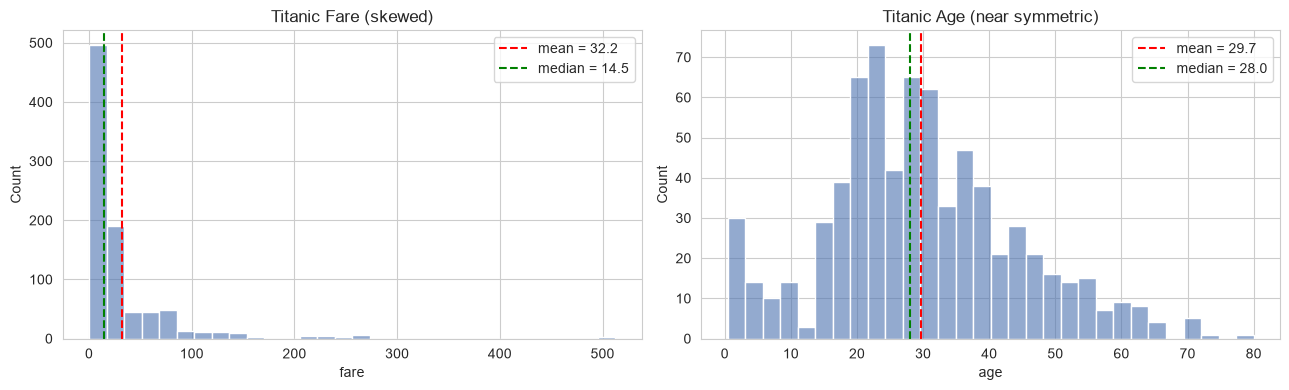

In [33]:
# [C5] 예제 1.3: 평균과 중앙값을 그림에 함께 — 분포가 한쪽으로 치우치면 두 값이 갈라진다
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(axes,
                          ["fare", "age"],
                          ["Titanic Fare (skewed)", "Titanic Age (near symmetric)"]):
    s = titanic[col].dropna()
    sns.histplot(s, bins=30, ax=ax, color="#4C72B0", alpha=0.6)
    ax.axvline(s.mean(),   color="red",   linestyle="--", label=f"mean = {s.mean():,.1f}")
    ax.axvline(s.median(), color="green", linestyle="--", label=f"median = {s.median():,.1f}")
    ax.set_title(title)
    ax.legend()

plt.tight_layout(); plt.show()

[문제]
1) visits(2년간 진료 방문 횟수)의 평균·중앙값·표준편차·IQR을 출력해보세요.
2) titanic["fare"]와 tips["total_bill"] 둘 다 "금액"인데, 두 변수의 변동계수(CV)를 비교해보세요.
   어떤 변수가 상대적으로 더 흔들립니까?
3) 같은 평균인데 표준편차가 큰 두 데이터가 있다면, 비즈니스 관점에서 어느 쪽이 예측하기
   어렵다고 할 수 있을지 판단과 근거를 주석으로 정리해보세요.
   - 표준편차가 큰 쪽이 훨씬 예측하기 어렵다, 평균은 장기적으로 반복했을때의 기대값일 뿐, 예측에는 큰 도움이 되지 않는다
   예측을 하기 위해서는 값의 범위가 좁은게 유리하므로 비즈니스적 관점에서 같은 평균이어도 표준편차가 큰 쪽이 훨씬 예측하기 어렵다.

In [34]:
visits = med["visits"].dropna()
print(f"visits n = {len(visits)}")
print(f"표본평균 x̄ = {visits.mean():,.2f}")
print(f"중앙값   = {visits.median():,.2f}")
print(f"표본표준편차 s = {visits.std():,.2f}")
print(f"Q1 = {visits.quantile(0.25):,.2f}")
print(f"Q3 = {visits.quantile(0.75):,.2f}")
print(f"IQR = Q3 - Q1 = {visits.quantile(0.75) - visits.quantile(0.25):,.2f}")
print(f"최솟값 = {visits.min():,.2f}, 최댓값 = {visits.max():,.2f}")  # 2년간 진료 방문 횟수 (0,1,2,… 이산형) → 포아송 후보

# ─────────────────────────────────────────────
# 2) 변동계수(CV, Coefficient of Variation) 비교
#    CV = 표준편차 / 평균  → 단위와 무관하게 "상대적 변동성"을 비교할 수 있음
#    (원, 달러처럼 단위가 다르거나, 평균 자체가 다른 두 변수를 비교할 때 필수)
# ─────────────────────────────────────────────

fare_mean, fare_std = titanic["fare"].mean(), titanic["fare"].std()
bill_mean, bill_std = tips["total_bill"].mean(), tips["total_bill"].std()

cv_fare = fare_std / fare_mean
cv_bill = bill_std / bill_mean

print(f"[타이타닉 운임(fare)]     평균={fare_mean:.2f}, 표준편차={fare_std:.2f}, CV={cv_fare:.3f}")
print(f"[식당 결제액(total_bill)] 평균={bill_mean:.2f}, 표준편차={bill_std:.2f}, CV={cv_bill:.3f}")

if cv_fare > cv_bill:
    print(f"\n→ fare가 상대적으로 더 흔들림 (CV {cv_fare:.2f} > {cv_bill:.2f})")
else:
    print(f"\n→ total_bill이 상대적으로 더 흔들림 (CV {cv_bill:.2f} > {cv_fare:.2f})")

visits n = 996
표본평균 x̄ = 1.93
중앙값   = 1.00
표본표준편차 s = 3.35
Q1 = 0.00
Q3 = 3.00
IQR = Q3 - Q1 = 3.00
최솟값 = 0.00, 최댓값 = 50.00
[타이타닉 운임(fare)]     평균=32.20, 표준편차=49.69, CV=1.543
[식당 결제액(total_bill)] 평균=19.79, 표준편차=8.90, CV=0.450

→ fare가 상대적으로 더 흔들림 (CV 1.54 > 0.45)


In [35]:
# [C7] 예제 2.1: 여러 실변수의 왜도·첨도를 한 표로
def summarize_shape(named_series):
    rows = []
    for name, s in named_series:
        s = s.dropna()
        rows.append({
            "변수": name,
            "평균": s.mean(),
            "중앙값": s.median(),
            "표준편차": s.std(),
            "왜도(skew)": stats.skew(s),
            "첨도(kurt)": stats.kurtosis(s),
        })
    return pd.DataFrame(rows).round(2)

shape_table = summarize_shape([
    ("titanic.fare",            titanic["fare"]),
    ("tips.total_bill",         tips["total_bill"]),
    ("titanic.age",             titanic["age"]),
    ("penguins.body_mass_g",    penguins["body_mass_g"]),
    ("penguins.flipper_len_mm", penguins["flipper_length_mm"]),
])
shape_table

,변수,평균,중앙값,표준편차,왜도(skew),첨도(kurt)
0,titanic.fare,32.20,14.45,49.69,4.78,33.20
1,tips.total_bill,19.79,17.80,8.90,1.13,1.17
2,titanic.age,29.70,28.00,14.53,0.39,0.17
3,penguins.body_mass_g,4201.75,4050.00,801.95,0.47,-0.73
4,penguins.flipper_len_mm,200.92,197.00,14.06,0.34,-0.99


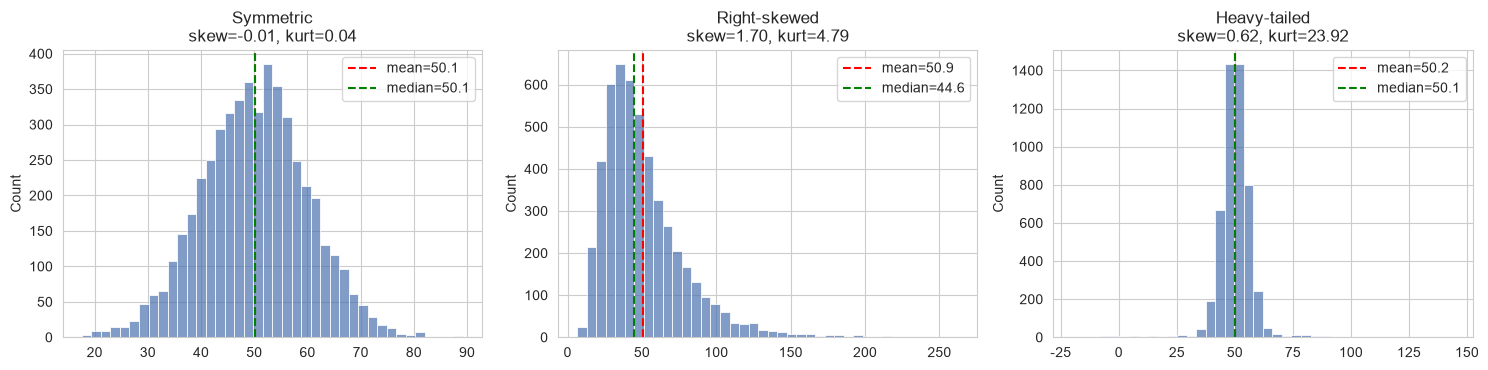

세 분포의 평균은 거의 같지만 모양은 전혀 다릅니다.


In [36]:
# [C8] 예제 2.2: 같은 평균인데 다른 모양 — 인공 데이터 세 개
np.random.seed(42)
N = 5000
sym  = np.random.normal(loc=50, scale=10, size=N)              # 좌우 대칭
right = np.random.lognormal(mean=np.log(45), sigma=0.5, size=N) # 우편향
heavy = np.concatenate([
    np.random.normal(loc=50, scale=5,  size=int(N*0.95)),
    np.random.normal(loc=50, scale=30, size=int(N*0.05)),       # 5% 극단값
])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, data, name in zip(axes,
                          [sym, right, heavy],
                          ["Symmetric", "Right-skewed", "Heavy-tailed"]):
    sns.histplot(data, bins=40, ax=ax, color="#4C72B0", alpha=0.7)
    ax.axvline(np.mean(data), color="red",   linestyle="--",
               label=f"mean={np.mean(data):.1f}")
    ax.axvline(np.median(data), color="green", linestyle="--",
               label=f"median={np.median(data):.1f}")
    ax.set_title(f"{name}\nskew={stats.skew(data):.2f}, kurt={stats.kurtosis(data):.2f}")
    ax.legend()
plt.tight_layout(); plt.show()

print("세 분포의 평균은 거의 같지만 모양은 전혀 다릅니다.")

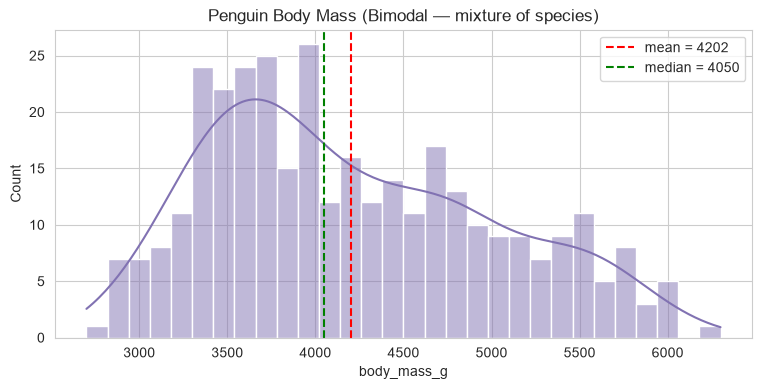

왜도: 0.47
첨도: -0.73  (음수 → 납작/다봉 신호)
→ 왜도가 0에 가깝다고 해서 정규분포라는 뜻은 아닙니다!


In [37]:
# [C9] 예제 2.3: 다봉 분포 — '평균'이 어디에도 없는 값일 때
bm = penguins["body_mass_g"].dropna()
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(bm, bins=30, kde=True, ax=ax, color="#8172B2")
ax.axvline(bm.mean(),   color="red",   linestyle="--", label=f"mean = {bm.mean():.0f}")
ax.axvline(bm.median(), color="green", linestyle="--", label=f"median = {bm.median():.0f}")
ax.set_title("Penguin Body Mass (Bimodal — mixture of species)")
ax.set_xlabel("body_mass_g")
ax.legend(); plt.show()

print(f"왜도: {stats.skew(bm):.2f}")
print(f"첨도: {stats.kurtosis(bm):.2f}  (음수 → 납작/다봉 신호)")
print("→ 왜도가 0에 가깝다고 해서 정규분포라는 뜻은 아닙니다!")

[문제]
1) titanic["fare"]의 왜도·첨도를 출력하고, 양의 왜도가 큰지 확인해보세요.
2) np.log1p(titanic["fare"])(로그 변환)의 왜도가 얼마나 줄어드는지 비교해보세요.
3) 어떤 변수의 왜도가 거의 0인데 첨도가 매우 크다면 분포 그림이 어떻게 생겼을지,
   추정과 근거를 주석으로 정리해보세요.
   - 거의 대칭인 상태로 양쪽 꼬리가 길고 매우 뾰족한 형태의 분포가 된다.
   왜도가 0에 가까우면 대칭의 형태를 띄게 되고 첨도가 매우 크면 굉장히 높은 분포가 된다 
   하지만 왜도가 0에 가깝다고 정규분포의 형태는 아니다.

In [38]:
# ─────────────────────────────────────────────
# 1) titanic["fare"]의 왜도(skewness) · 첨도(kurtosis)
# ─────────────────────────────────────────────

fare_skew = titanic["fare"].skew()
fare_kurt = titanic["fare"].kurt()   # pandas는 기본적으로 "초과 첨도(excess kurtosis)"를 반환 (정규분포=0 기준)

print(f"fare 왜도(skewness) = {fare_skew:.3f}")
print(f"fare 첨도(kurtosis) = {fare_kurt:.3f}")

if fare_skew > 1:
    print("→ 왜도가 1보다 커서 '심한 양의 왜도(right-skewed)'로 판단할 수 있음")
elif fare_skew > 0:
    print("→ 양의 왜도(오른쪽 꼬리가 긴 분포)이지만 정도는 상대적으로 약함")
else:
    print("→ 음의 왜도 혹은 대칭에 가까움")

fare 왜도(skewness) = 4.787
fare 첨도(kurtosis) = 33.398
→ 왜도가 1보다 커서 '심한 양의 왜도(right-skewed)'로 판단할 수 있음


In [39]:
# ─────────────────────────────────────────────
# 2) 로그 변환 후 왜도 비교
#    log1p(x) = log(1+x)  → 0값이 있어도 안전하게 로그를 취할 수 있음
# ─────────────────────────────────────────────

fare_log = np.log1p(titanic["fare"])
fare_log_skew = fare_log.skew()

print(f"원본 fare        왜도 = {fare_skew:.3f}")
print(f"log1p(fare)      왜도 = {fare_log_skew:.3f}")
print(f"왜도 감소폭       = {fare_skew - fare_log_skew:.3f}")
print(f"감소율           = {(1 - fare_log_skew/fare_skew) * 100:.1f}%")

원본 fare        왜도 = 4.787
log1p(fare)      왜도 = 0.395
왜도 감소폭       = 4.392
감소율           = 91.8%


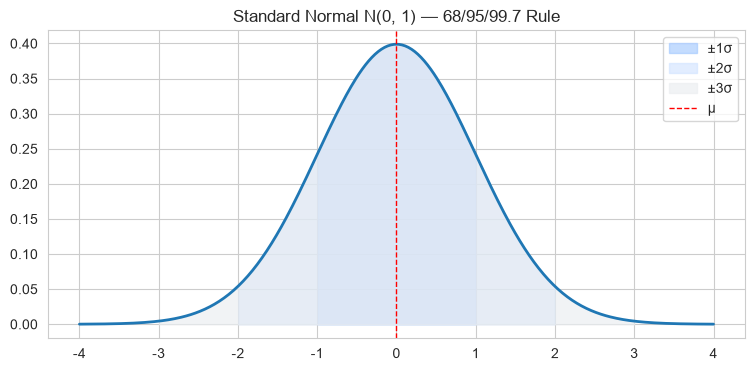

±1σ 안 확률: 0.683
±2σ 안 확률: 0.954
±3σ 안 확률: 0.997


In [40]:
# [C11] 예제 3.1: 정규분포 PDF — 68-95-99.7 규칙
mu, sigma = 0, 1
x = np.linspace(-4, 4, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, pdf, lw=2)
for k, color in zip([1, 2, 3], ["#9ec5fe", "#cfe2ff", "#e9ecef"]):
    ax.fill_between(x, pdf, where=(x >= -k) & (x <= k), color=color, alpha=0.6,
                    label=f"±{k}σ")
ax.axvline(mu, color="red", linestyle="--", lw=1, label="μ")
ax.set_title("Standard Normal N(0, 1) — 68/95/99.7 Rule")
ax.legend(); plt.show()

print("±1σ 안 확률:", round(stats.norm.cdf(1) - stats.norm.cdf(-1), 3))
print("±2σ 안 확률:", round(stats.norm.cdf(2) - stats.norm.cdf(-2), 3))
print("±3σ 안 확률:", round(stats.norm.cdf(3) - stats.norm.cdf(-3), 3))

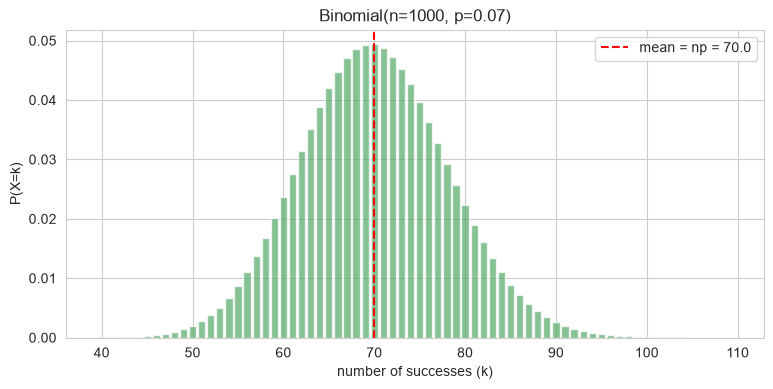

이론 평균(np): 70.0, 표본평균: 69.6
이론 표준편차: 8.07, 표본표준편차: 8.07


In [41]:
# [C12] 예제 3.2: 이항분포 — n=1000, p=0.07 (쿠폰 사용 횟수)
n_trials, p = 1000, 0.07
x = np.arange(40, 110)
pmf = stats.binom.pmf(x, n_trials, p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x, pmf, color="#55A868", alpha=0.7)
ax.axvline(n_trials * p, color="red", linestyle="--", label=f"mean = np = {n_trials*p}")
ax.set_title(f"Binomial(n={n_trials}, p={p})")
ax.set_xlabel("number of successes (k)"); ax.set_ylabel("P(X=k)")
ax.legend(); plt.show()

# 같은 분포에서 표본을 뽑아 이론과 비교 (시뮬레이션, seed 고정)
sample = stats.binom.rvs(n_trials, p, size=365, random_state=42)
print(f"이론 평균(np): {n_trials*p:.1f}, 표본평균: {sample.mean():.1f}")
print(f"이론 표준편차: {np.sqrt(n_trials*p*(1-p)):.2f}, 표본표준편차: {sample.std():.2f}")

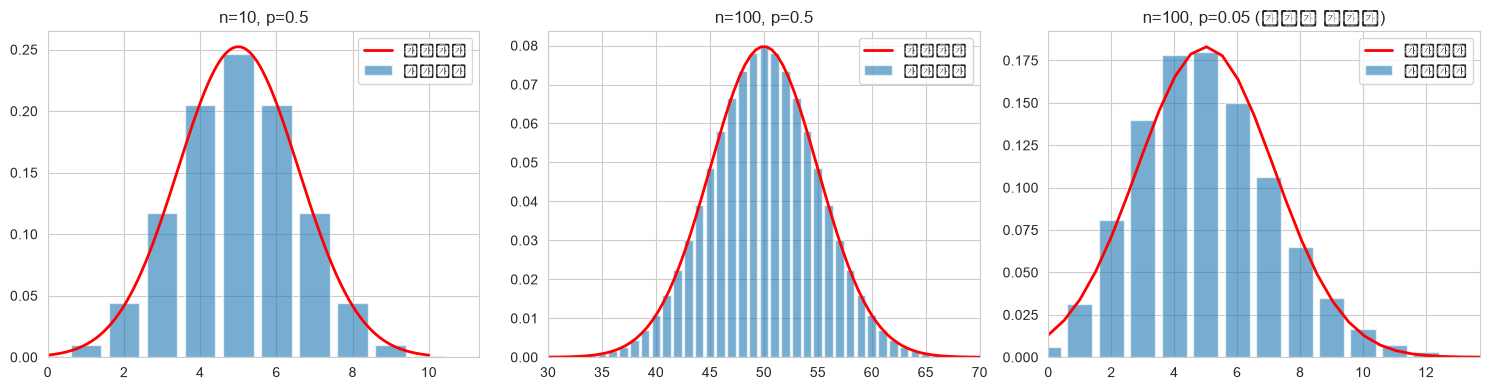

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    (10, 0.5, "n=10, p=0.5"),
    (100, 0.5, "n=100, p=0.5"),
    (100, 0.05, "n=100, p=0.05 (여전히 치우침)")
]

for ax, (n, p, title) in zip(axes, configs):
    k = np.arange(0, n+1)
    pmf = binom.pmf(k, n, p)
    ax.bar(k, pmf, alpha=0.6, label="이항분포")

    mu, sigma = n*p, np.sqrt(n*p*(1-p))
    x = np.linspace(0, n, 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label="정규근사")
    ax.set_title(title)
    ax.set_xlim(max(0, mu-4*sigma), mu+4*sigma)
    ax.legend()

plt.tight_layout()
plt.savefig("binomial_normal.png", dpi=100)
plt.show()

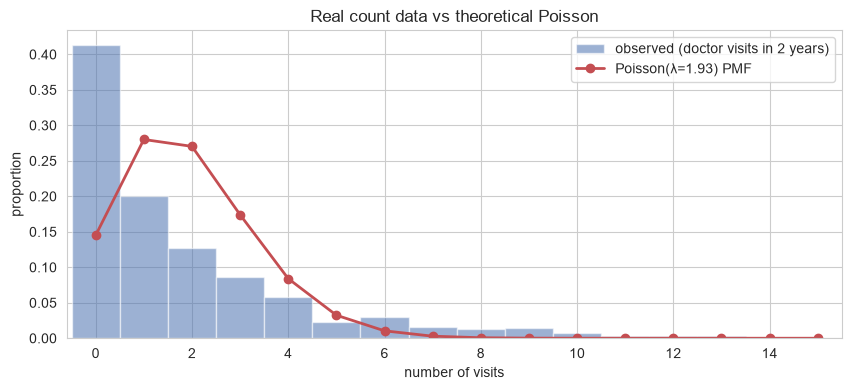

■ 포아송 가정 점검 ①  평균 ≈ 분산인가?
   표본평균 1.93   표본분산 11.25
   분산/평균 = 5.83   (1이면 포아송, 1보다 크면 '과대산포')

■ 포아송 가정 점검 ②  0회의 비율이 이론과 맞는가?
   관측 0회 비율      41.2%
   포아송이 예측하는 값 14.5%


In [43]:
# [C13] 예제 3.3: 포아송 — 실데이터('2년간 진료 방문 횟수')와 이론 PMF 비교
lam = visits.mean()                       # λ 추정치 = 표본평균
x = np.arange(0, 16)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(visits, bins=np.arange(0, 17) - 0.5, density=True, alpha=0.55,
        color="#4C72B0", label="observed (doctor visits in 2 years)")
ax.plot(x, stats.poisson.pmf(x, lam), "o-", color="#C44E52", lw=2,
        label=f"Poisson(λ={lam:.2f}) PMF")
ax.set_xlim(-0.6, 15.5)
ax.set_xlabel("number of visits"); ax.set_ylabel("proportion")
ax.set_title("Real count data vs theoretical Poisson")
ax.legend(); plt.show()

print("■ 포아송 가정 점검 ①  평균 ≈ 분산인가?")
print(f"   표본평균 {visits.mean():.2f}   표본분산 {visits.var():.2f}")
print(f"   분산/평균 = {visits.var() / visits.mean():.2f}   (1이면 포아송, 1보다 크면 '과대산포')")
print("\n■ 포아송 가정 점검 ②  0회의 비율이 이론과 맞는가?")
print(f"   관측 0회 비율      {np.mean(visits == 0):.1%}")
print(f"   포아송이 예측하는 값 {stats.poisson.pmf(0, lam):.1%}")

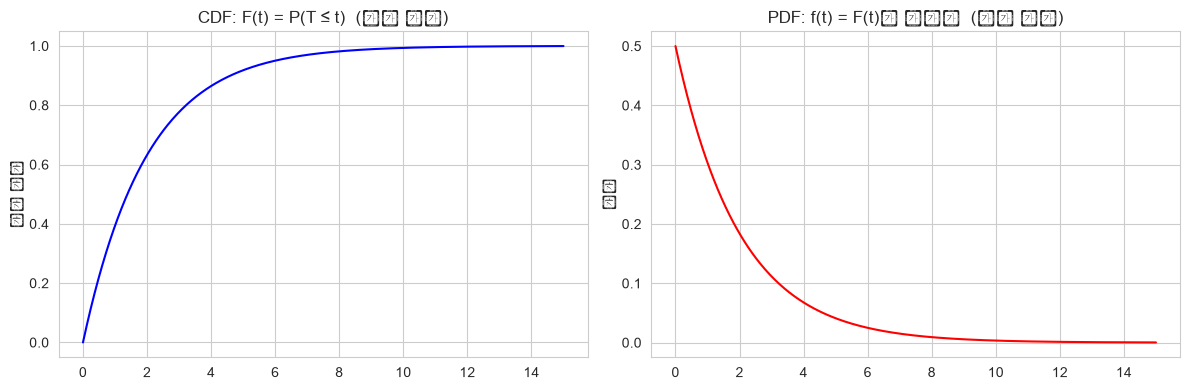

t=2 에서 CDF의 수치미분: 0.1826609533543877
t=2 에서 이론적 PDF:     0.18393972058572117


In [44]:
#CDF PDF 차이
import numpy as np
import matplotlib.pyplot as plt

lam = 0.5
t = np.linspace(0, 15, 500)

cdf = 1 - np.exp(-lam * t)      # F(t)
pdf = lam * np.exp(-lam * t)    # f(t)  = F(t)를 미분한 것

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, cdf, color='blue')
axes[0].set_title("CDF: F(t) = P(T ≤ t)  (누적 확률)")
axes[0].set_ylabel("누적 확률")

axes[1].plot(t, pdf, color='red')
axes[1].set_title("PDF: f(t) = F(t)의 기울기  (확률 밀도)")
axes[1].set_ylabel("밀도")

plt.tight_layout()
plt.savefig("cdf_vs_pdf.png", dpi=100)
plt.show()

# 수치적으로도 확인: CDF의 기울기(수치미분) ≈ PDF
numerical_derivative = np.gradient(cdf, t)
print("t=2 에서 CDF의 수치미분:", numerical_derivative[np.argmin(np.abs(t-2))])
print("t=2 에서 이론적 PDF:    ", lam * np.exp(-lam*2))

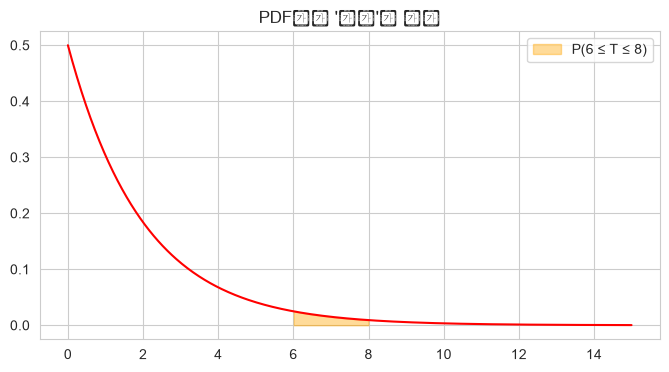

P(6 ≤ T ≤ 8) = 0.0315


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

lam = 0.5
t = np.linspace(0, 15, 500)
pdf = expon.pdf(t, scale=1/lam)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(t, pdf, color='red')

# 6~8일 사이 구간에 색칠 (이 넓이가 곧 확률)
mask = (t >= 6) & (t <= 8)
ax.fill_between(t[mask], pdf[mask], alpha=0.4, color='orange', label="P(6 ≤ T ≤ 8)")
ax.legend()
ax.set_title("PDF에서 '넓이'가 확률")
plt.savefig("pdf_area.png", dpi=100)
plt.show()

# 실제 확률 계산: 적분 (=CDF 차이로 간단히 구함)
prob = expon.cdf(8, scale=1/lam) - expon.cdf(6, scale=1/lam)
print(f"P(6 ≤ T ≤ 8) = {prob:.4f}")

In [46]:
from scipy.stats import expon

lam = 0.5

# P(T ≤ 5) : 5일 이내에 파업이 끝날 확률
print("P(T≤5) =", expon.cdf(5, scale=1/lam))

# P(T > 5) : 5일 넘게 지속될 확률
print("P(T>5) =", 1 - expon.cdf(5, scale=1/lam))
print("P(T>5) =", expon.sf(5, scale=1/lam))  # sf = survival function, 1-cdf와 동일

# P(3 ≤ T ≤ 7) : 구간 확률
print("P(3≤T≤7) =", expon.cdf(7, scale=1/lam) - expon.cdf(3, scale=1/lam))

P(T≤5) = 0.9179150013761012
P(T>5) = 0.08208499862389884
P(T>5) = 0.0820849986238988
P(3≤T≤7) = 0.1929327767261113


In [47]:
from scipy.stats import t

t_stat = 2.5
df = 48
p_value = 2 * (1 - t.cdf(abs(t_stat), df))   # 양측검정 p-value
print(p_value)

0.015889690934237644


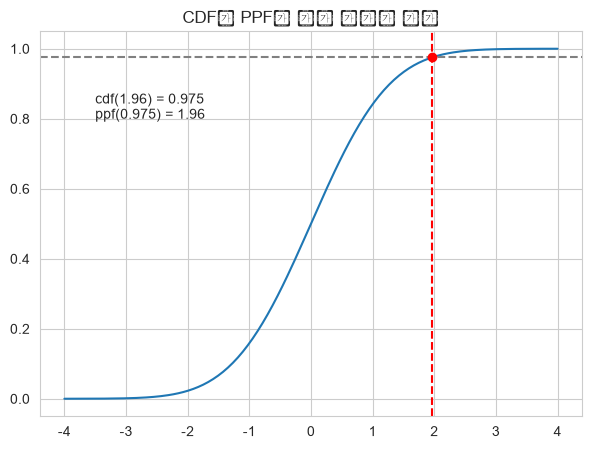

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

x = np.linspace(-4, 4, 200)
cdf_vals = norm.cdf(x)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(x, cdf_vals)
ax.axhline(0.975, color='gray', linestyle='--')
ax.axvline(norm.ppf(0.975), color='red', linestyle='--')
ax.scatter([norm.ppf(0.975)], [0.975], color='red', zorder=5)
ax.annotate(f"cdf(1.96) = 0.975\nppf(0.975) = 1.96",
            xy=(norm.ppf(0.975), 0.975), xytext=(-3.5, 0.8))
ax.set_title("CDF와 PPF는 서로 역함수 관계")
plt.savefig("cdf_ppf.png", dpi=100)
plt.show()

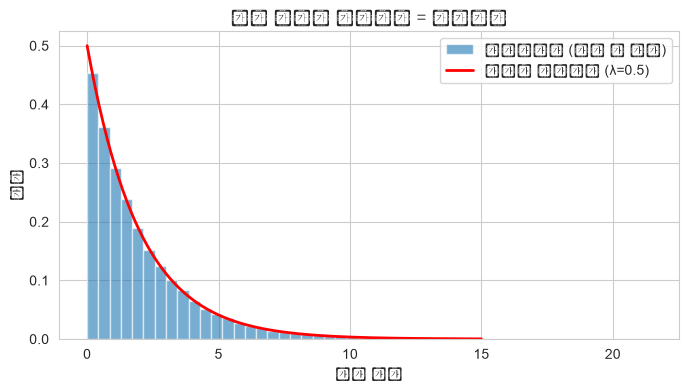

시뮬레이션 평균 대기시간: 2.00
이론적 평균 (1/λ):        2.00


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, poisson

lam = 0.5   # 단위 시간당 평균 0.5건 발생 (예: 평균 대기시간 = 1/0.5 = 2)

# 시뮬레이션: 포아송 과정을 직접 만들어서 "사건 사이 간격"이 지수분포인지 확인
np.random.seed(0)
n_events = 100_000
inter_arrival_times = np.random.exponential(scale=1/lam, size=n_events)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(inter_arrival_times, bins=50, density=True, alpha=0.6, label="시뮬레이션 (사건 간 간격)")

x = np.linspace(0, 15, 200)
ax.plot(x, expon.pdf(x, scale=1/lam), 'r-', lw=2, label=f"이론적 지수분포 (λ={lam})")
ax.set_xlabel("대기 시간")
ax.set_ylabel("밀도")
ax.legend()
ax.set_title("사건 사이의 대기시간 = 지수분포")
plt.savefig("exponential_demo.png", dpi=100)
plt.show()

print(f"시뮬레이션 평균 대기시간: {inter_arrival_times.mean():.2f}")
print(f"이론적 평균 (1/λ):        {1/lam:.2f}")

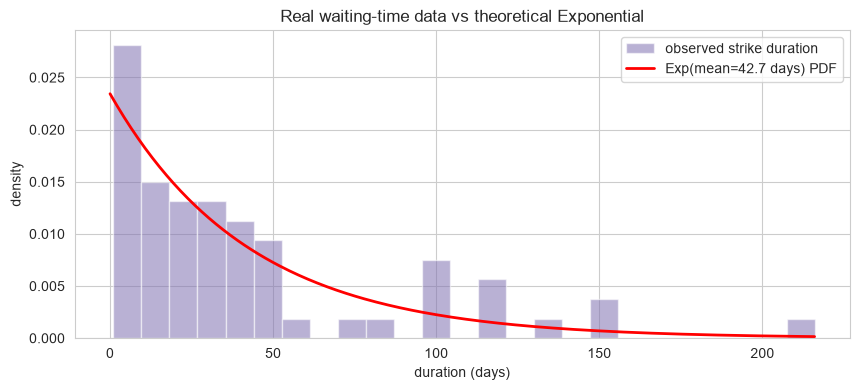

■ 지수분포 판정 신호: 평균 ≈ 표준편차인가?
   표본평균     42.7일
   표본표준편차 45.9일
   표준편차/평균 = 1.07   (1에 가까울수록 지수분포 닮음)

   21일 안에 끝난 파업 비율 : 관측 41.9% / 지수분포 예측 39.3%


In [50]:
# [C14] 예제 3.4: 지수분포 — 실데이터('파업 지속일수')와 이론 PDF 비교
mean_wait = wait.mean()
x = np.linspace(0, wait.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(wait, bins=25, density=True, alpha=0.55, color="#8172B2",
        label="observed strike duration")
ax.plot(x, stats.expon.pdf(x, scale=mean_wait), color="red", lw=2,
        label=f"Exp(mean={mean_wait:.1f} days) PDF")
ax.set_xlabel("duration (days)"); ax.set_ylabel("density")
ax.set_title("Real waiting-time data vs theoretical Exponential")
ax.legend(); plt.show()

print("■ 지수분포 판정 신호: 평균 ≈ 표준편차인가?")
print(f"   표본평균     {wait.mean():.1f}일")
print(f"   표본표준편차 {wait.std():.1f}일")
print(f"   표준편차/평균 = {wait.std() / wait.mean():.2f}   (1에 가까울수록 지수분포 닮음)")

# 지수분포가 맞다면, '평균의 절반보다 짧게 끝날 확률'은 이론적으로 약 39%
half = mean_wait / 2
print(f"\n   {half:.0f}일 안에 끝난 파업 비율 : 관측 {np.mean(wait <= half):.1%}"
      f" / 지수분포 예측 {stats.expon.cdf(half, scale=mean_wait):.1%}")

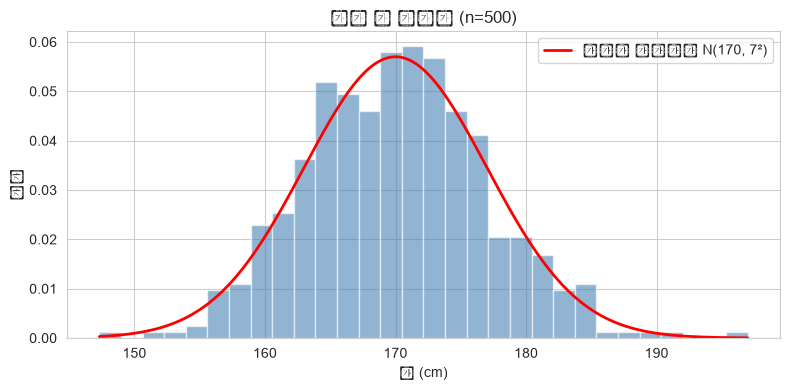

표본 평균: 170.05, 표본 표준편차: 6.86
→ loc=170, scale=7로 설정한 값과 거의 비슷하게 나오는지 확인

시간당 통화 수 (n=500)
표본 평균: 4.992
표본 분산: 5.116
분산/평균 비율: 1.025  (1에 가까우면 포아송 가정과 일치)


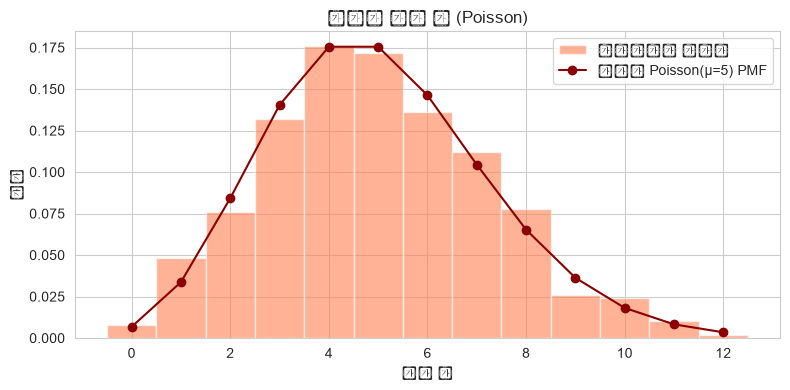

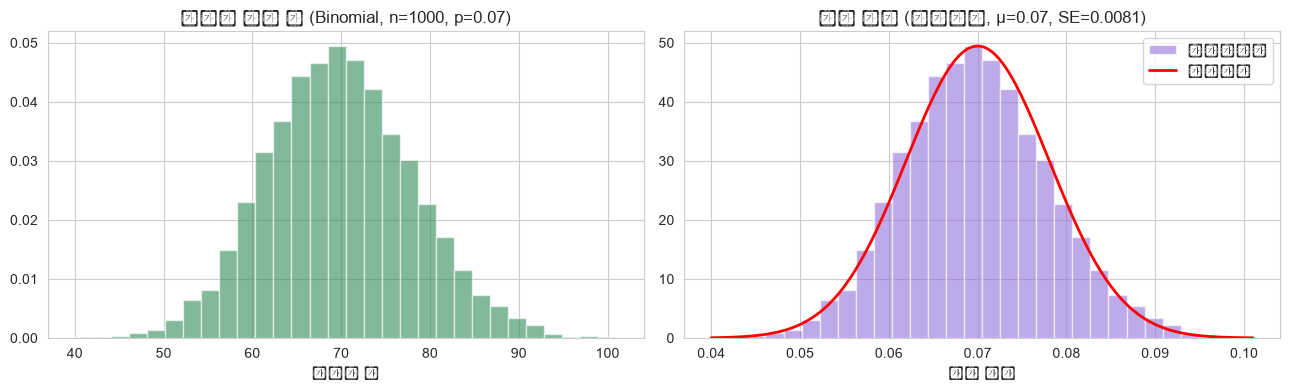


이항분포(사람 수) 평균: 69.86, 표준편차: 8.06
이론값: 평균=70.0, 표준편차=8.07

비율 평균: 0.0699, 표준오차: 0.0081
이론값: 평균=0.07, 표준오차=0.0081


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ─────────────────────────────────────────────
# 1) 가상 키 데이터 (정규분포) — 연속형, 측정값
# ─────────────────────────────────────────────

np.random.seed(42)
heights = stats.norm.rvs(loc=170, scale=7, size=500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(heights, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='white')

# 이론적 정규분포 곡선 겹쳐 그리기
x = np.linspace(heights.min(), heights.max(), 200)
ax.plot(x, stats.norm.pdf(x, loc=170, scale=7), 'r-', lw=2, label="이론적 정규분포 N(170, 7²)")

ax.set_title("가상 키 데이터 (n=500)")
ax.set_xlabel("키 (cm)")
ax.set_ylabel("밀도")
ax.legend()
plt.tight_layout()
plt.savefig("height_hist.png", dpi=100)
plt.show()

print(f"표본 평균: {heights.mean():.2f}, 표본 표준편차: {heights.std():.2f}")
print("→ loc=170, scale=7로 설정한 값과 거의 비슷하게 나오는지 확인")


# ─────────────────────────────────────────────
# 2) 시간당 통화 수 (포아송분포) — 이산형, 카운트
# ─────────────────────────────────────────────

calls = stats.poisson.rvs(mu=5, size=500)

calls_mean = calls.mean()
calls_var = calls.var()

print(f"\n시간당 통화 수 (n=500)")
print(f"표본 평균: {calls_mean:.3f}")
print(f"표본 분산: {calls_var:.3f}")
print(f"분산/평균 비율: {calls_var / calls_mean:.3f}  (1에 가까우면 포아송 가정과 일치)")

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(calls.min(), calls.max() + 2) - 0.5
ax.hist(calls, bins=bins, density=True, alpha=0.6, color='coral', edgecolor='white', label="시뮬레이션 데이터")

k = np.arange(0, calls.max() + 1)
ax.plot(k, stats.poisson.pmf(k, mu=5), 'o-', color='darkred', label="이론적 Poisson(μ=5) PMF")

ax.set_title("시간당 통화 수 (Poisson)")
ax.set_xlabel("통화 수")
ax.set_ylabel("비율")
ax.legend()
plt.tight_layout()
plt.savefig("calls_hist.png", dpi=100)
plt.show()

n, p = 1000, 0.07

# 이항분포로 직접 시뮬레이션
np.random.seed(0)
coupon_users = stats.binom.rvs(n=n, p=p, size=10000)  # "1000명 중 사용자 수"를 만번 반복 시뮬레이션

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (좌) 이항분포: 사용한 "사람 수"
axes[0].hist(coupon_users, bins=30, density=True, alpha=0.6, color='seagreen')
axes[0].set_title(f"사용한 사람 수 (Binomial, n={n}, p={p})")
axes[0].set_xlabel("사용자 수")

# (우) 비율로 변환: 사용 "비율"
usage_rate = coupon_users / n
axes[1].hist(usage_rate, bins=30, density=True, alpha=0.6, color='mediumpurple', label="시뮬레이션")

# 정규근사 곡선 겹치기
se = np.sqrt(p * (1-p) / n)   # 표준오차
x = np.linspace(usage_rate.min(), usage_rate.max(), 200)
axes[1].plot(x, stats.norm.pdf(x, loc=p, scale=se), 'r-', lw=2, label="정규근사")
axes[1].set_title(f"사용 비율 (정규근사, μ={p}, SE={se:.4f})")
axes[1].set_xlabel("사용 비율")
axes[1].legend()

plt.tight_layout()
plt.savefig("coupon_binomial_vs_normal.png", dpi=100)
plt.show()

print(f"\n이항분포(사람 수) 평균: {coupon_users.mean():.2f}, 표준편차: {coupon_users.std():.2f}")
print(f"이론값: 평균={n*p}, 표준편차={np.sqrt(n*p*(1-p)):.2f}")
print(f"\n비율 평균: {usage_rate.mean():.4f}, 표준오차: {usage_rate.std():.4f}")
print(f"이론값: 평균={p}, 표준오차={se:.4f}")

In [ ]:
# ─────────────────────────────────────────────
# 3) "쿠폰 발송 1000명 중 사용한 사람 수" → 어떤 분포?
# ─────────────────────────────────────────────

# 판단 및 근거 (주석 정리):
#
# [사용한 "사람 수"로 볼 때 — 이항분포(Binomial)]
#   - 1000명이라는 "정해진 시행 횟수(n)"가 있고,
#     각 사람은 "사용했다/안 했다"라는 독립적인 베르누이 시행(성공확률 p=0.07)을 겪음.
#   - 이런 "고정된 n번의 독립시행 중 성공 횟수"는 이항분포의 정의와 정확히 일치.
#   → X ~ Binomial(n=1000, p=0.07)
#
#   다만 n이 매우 크고 p가 작지 않다면(np=70, n(1-p)=930 모두 충분히 큼),
#   이항분포는 정규분포로 근사가 잘 되는 영역에 들어감 (np≥5, n(1-p)≥5 조건 만족).
#   → 실무에서는 정규근사로 신뢰구간을 간단히 계산하기도 함.
#
#   * 참고: 만약 "사용한 사람 수"가 아니라 n이 매우 크고 p가 매우 작은 극단적 상황
#     (예: 100만 명 중 사용률 0.01%)이라면 포아송 근사가 더 적합할 수도 있음.
#     하지만 지금처럼 p=7%는 "작다"고 보기 어려워서 포아송보다는
#     이항(혹은 정규근사)이 더 자연스러움.
#
# [같은 데이터를 "비율(7%)" 단위로 볼 때 — 정규분포(Normal)로 근사]
#   - "1000명 중 사용한 사람의 비율(p-hat)"은 이항분포를 n(=1000)으로 나눈 값.
#   - 표본 크기가 충분히 크면(중심극한정리), 이 비율(p-hat)의 분포는
#     평균 p=0.07, 표준오차 sqrt(p(1-p)/n) 인 정규분포에 가까워짐.
#   - 그래서 "전환율이 7%±α%"처럼 신뢰구간을 말할 때는
#     이항분포 자체보다 정규근사를 이용한 비율 신뢰구간 공식을 사용하는 게 실무 표준.
#
# 결론:
#   - "사용한 사람 수"(정수, count) → 이항분포가 원리적으로 정확한 모델
#   - "사용 비율"(연속적인 %) → 정규분포로 근사해서 다루는 게 실무적으로 편리
#   - 즉, 같은 현상이라도 "무엇을 확률변수로 잡느냐"에 따라
#     이산형(이항)으로 볼 수도, 연속형(정규 근사)으로 볼 수도 있음.